# INF280 - Estadística Computacional
## Laboratorio 2: Simulación e Inferencia

**Grupo 10**

| Integrante | Rol |
|---|---|
| Emilio Araya | Integrante |
| Benjamín Lira | Integrante |
| Nicolás Muñoz | Integrante |
| Jaime Muena | Integrante |

**Universidad Técnica Federico Santa María — Campus San Joaquín**  
**Fecha de entrega:** 10 de mayo de 2026

---
## Sección 0: Contexto y Recordatorio del Laboratorio 1

### Dataset
Trabajamos con el dataset **Health Insurance Cost and Risk** (Kaggle), que contiene información de 1338 beneficiarios de seguros de salud. Tras eliminar filas con valores faltantes (`dropna`), el dataset queda con **n = 1337 observaciones** y 12 variables.

### Variables clave seleccionadas en el Lab 1
| Variable | Tipo | Rol |
|---|---|---|
| `charges` | Continua | Variable objetivo (costo médico facturado) |
| `smoker` | Categórica (Sí/No) | Factor principal de diferenciación |
| `bmi` | Continua | Modulador no-lineal del costo |
| `age` | Continua | Variable de control |

### Hipótesis de investigación (Lab 1)
> **"¿Existe una diferencia estadísticamente significativa en los costos médicos facturados entre los pacientes fumadores y no fumadores, y esta diferencia se agrava de forma no lineal cuando el paciente presenta un índice de masa corporal correspondiente a obesidad (mayor a 30)?"**

### Hallazgos clave del EDA
1. `charges` está fuertemente sesgada a la derecha (no sigue una distribución normal).
2. La mediana de costos para fumadores es drásticamente mayor; incluso el mínimo de un fumador supera el promedio de un no fumador.
3. Si BMI > 30 **y** el paciente es fumador, los costos sufren un incremento exponencial (efecto interactivo no-lineal).
4. La edad muestra una tendencia ascendente lineal con `charges`, dividida en franjas marcadas por `smoker`.

Este laboratorio busca responder la hipótesis anterior mediante **estimación puntual**, **bootstrap** y **simulación Monte Carlo**.

---
## Setup: Imports, Configuración Global y Carga de Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Setup OK ✓")

Setup OK ✓


In [2]:
df = pd.read_csv('health_insurance_cost_and_risk_dataset.csv')
df['smoker'] = df['smoker'].map({'yes': 'Sí', 'no': 'No'})
df_limpio = df.dropna().copy()

print(f"Filas originales : {len(df):,}")
print(f"Filas tras dropna: {len(df_limpio):,}")
print(f"Columnas         : {list(df_limpio.columns)}")

Filas originales : 1,338
Filas tras dropna: 1,335
Columnas         : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'blood_pressure', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk', 'annual_income']


In [3]:
fumadores    = df_limpio[df_limpio['smoker'] == 'Sí']
no_fumadores = df_limpio[df_limpio['smoker'] == 'No']

fum_obeso    = fumadores[fumadores['bmi'] > 30]
fum_no_obeso = fumadores[fumadores['bmi'] <= 30]

resumen_grupos = pd.DataFrame({
    'Grupo': [
        'Total (limpio)',
        'Fumadores',
        'No fumadores',
        'Fumadores con BMI > 30 (obesos)',
        'Fumadores con BMI ≤ 30 (no obesos)'
    ],
    'n': [
        len(df_limpio),
        len(fumadores),
        len(no_fumadores),
        len(fum_obeso),
        len(fum_no_obeso)
    ]
})
resumen_grupos['%'] = (resumen_grupos['n'] / len(df_limpio) * 100).round(1)

print("Tamaños muestrales por subgrupo:")
print(resumen_grupos.to_string(index=False))

Tamaños muestrales por subgrupo:
                             Grupo    n      %
                    Total (limpio) 1335 100.00
                         Fumadores  273  20.40
                      No fumadores 1062  79.60
   Fumadores con BMI > 30 (obesos)  144  10.80
Fumadores con BMI ≤ 30 (no obesos)  129   9.70


---
## Sección 1: Definición del Parámetro de Interés y Estimación Puntual

### 1.1 Definición formal de los parámetros de interés

Retomando la hipótesis planteada en el Laboratorio 1:

> **"¿Existe una diferencia estadísticamente significativa en los costos médicos facturados
> entre los pacientes fumadores y no fumadores, y esta diferencia se agrava de forma no lineal
> cuando el paciente presenta un índice de masa corporal correspondiente a obesidad (mayor a 30)?"**

Esta hipótesis tiene dos componentes diferenciables, cada uno de los cuales se formaliza
como un parámetro poblacional distinto:

**Parámetro 1 — Efecto global del tabaquismo:**

$$\theta_1 = \mu_{\text{charges} \mid \text{fumador}} - \mu_{\text{charges} \mid \text{no fumador}}$$

Representa la diferencia entre el costo médico promedio de la población fumadora y la no fumadora.
Un valor de $\theta_1 > 0$ indica que fumar está asociado a mayores costos médicos en promedio.
Este parámetro responde directamente al primer componente de la hipótesis.

**Parámetro 2 — Agravamiento por obesidad dentro del grupo fumador:**

$$\theta_2 = \mu_{\text{charges} \mid \text{fumador, BMI} > 30} - \mu_{\text{charges} \mid \text{fumador, BMI} \leq 30}$$

Representa la diferencia en costos médicos promedio entre fumadores obesos (BMI > 30) y fumadores
no obesos, dentro del mismo grupo de fumadores. Aislar el análisis al grupo fumador es clave:
si $\theta_2 > 0$ y es significativamente mayor que el efecto del BMI en no fumadores,
evidenciamos la interacción no-lineal que la hipótesis plantea.

**Tabla de trazabilidad hipótesis → parámetro → estimador:**

| Componente de la hipótesis | Parámetro poblacional | Estimador muestral |
|---|---|---|
| Diferencia fumador vs. no fumador | $\theta_1 = \mu_F - \mu_{NF}$ | $\hat{\theta}_1 = \bar{X}_F - \bar{X}_{NF}$ |
| Agravamiento por obesidad (fumadores) | $\theta_2 = \mu_{F,O} - \mu_{F,NO}$ | $\hat{\theta}_2 = \bar{X}_{F,O} - \bar{X}_{F,NO}$ |

Ambos parámetros son **diferencias de medias entre subgrupos independientes**, lo que permite
un tratamiento metodológico paralelo y coherente en las secciones de estimación puntual y bootstrap.
La elección de la **media** como estadístico base se justifica por su eficiencia asintótica
(TCL) y por la interpretabilidad directa en términos de costo promedio por asegurado.
Se discute la alternativa de la mediana más adelante.

In [4]:
# ── Estimación puntual clásica ────────────────────────────────────────────────
from scipy import stats

def estimacion_clasica(grupo1, grupo2, nombre_param, alpha=0.05):
    """
    Calcula estimador puntual, EE y IC clásico (Welch) para diferencia de medias.
    Devuelve un dict con los resultados.
    """
    n1, n2 = len(grupo1), len(grupo2)
    media1, media2 = grupo1.mean(), grupo2.mean()
    theta_hat = media1 - media2
    
    # Error estándar de Welch (no asume igualdad de varianzas)
    var1, var2 = grupo1.var(ddof=1), grupo2.var(ddof=1)
    ee = np.sqrt(var1/n1 + var2/n2)
    
    # Grados de libertad de Welch
    gl = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
    
    # IC con distribución t
    t_crit = stats.t.ppf(1 - alpha/2, df=gl)
    ic_inf = theta_hat - t_crit * ee
    ic_sup = theta_hat + t_crit * ee
    
    return {
        'Parámetro': nombre_param,
        'n grupo 1': n1,
        'n grupo 2': n2,
        'Media grupo 1 ($)': round(media1, 2),
        'Media grupo 2 ($)': round(media2, 2),
        'Estimador θ̂ ($)': round(theta_hat, 2),
        'Error Estándar ($)': round(ee, 2),
        'IC 95% inferior ($)': round(ic_inf, 2),
        'IC 95% superior ($)': round(ic_sup, 2),
    }

# Calcular para θ₁ y θ₂
resultado_theta1 = estimacion_clasica(
    fumadores['charges'], no_fumadores['charges'],
    'θ₁ (fumador vs. no fumador)'
)
resultado_theta2 = estimacion_clasica(
    fum_obeso['charges'], fum_no_obeso['charges'],
    'θ₂ (fum. obeso vs. fum. no obeso)'
)

tabla_estimacion = pd.DataFrame([resultado_theta1, resultado_theta2])
print("Tabla de estimación puntual clásica:")
display(tabla_estimacion.set_index('Parámetro'))

Tabla de estimación puntual clásica:


,n grupo 1,n grupo 2,Media grupo 1 ($),Media grupo 2 ($),Estimador θ̂ ($),Error Estándar ($),IC 95% inferior ($),IC 95% superior ($)
Parámetro,,,,,,,,
θ₁ (fumador vs. no fumador),273,1062,"32,060.89","8,421.20","23,639.69",723.26,"22,216.58","25,062.80"
θ₂ (fum. obeso vs. fum. no obeso),144,129,"41,692.81","21,308.97","20,383.83",656.75,"19,090.84","21,676.83"


### 1.3 Propiedades del estimador

El estimador $\hat{\theta} = \bar{X}_1 - \bar{X}_2$ (diferencia de medias muestrales) posee
tres propiedades fundamentales que lo hacen adecuado para este problema:

**Insesgadez:** Por la linealidad del operador esperanza,
$\mathbb{E}[\hat{\theta}] = \mathbb{E}[\bar{X}_1] - \mathbb{E}[\bar{X}_2] = \mu_1 - \mu_2 = \theta$.
El estimador no sobreestima ni subestima sistemáticamente el parámetro verdadero.

**Consistencia:** Por la Ley de los Grandes Números, $\bar{X}_i \xrightarrow{P} \mu_i$
cuando $n_i \to \infty$. Por tanto, $\hat{\theta} \xrightarrow{P} \theta$: a mayor tamaño muestral,
la estimación converge al valor verdadero.

**Eficiencia asintótica:** Por el Teorema Central del Límite,
$\sqrt{n}(\hat{\theta} - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$,
donde $\sigma^2 = \text{Var}(X_1)/n_1 + \text{Var}(X_2)/n_2$.
En la clase de estimadores lineales insesgados, la diferencia de medias es asintóticamente
eficiente (alcanza la cota de Cramér-Rao asintótica).

**Caveat — sesgo de `charges`:** La distribución de costos médicos es fuertemente
asimétrica a la derecha (como evidenció el Lab 1). En este contexto, la **mediana** sería
un estimador más robusto a valores extremos. Sin embargo, **mantenemos la media** como
parámetro de interés por dos razones: (1) es el estadístico relevante para decisiones actuariales
(el costo total esperado de una cartera es la suma de medias), y (2) la teoría asintótica
del bootstrap opera sobre la distribución muestral de la media, lo que permite visualizar
e interpretar la distribución bootstrap de manera directa. El sesgo a la derecha de `charges`
precisamente *motiva* el uso de bootstrap en la siguiente sección.

C:\Users\emili\AppData\Local\Temp\ipykernel_4508\825781966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='smoker', y='charges', palette='Set1',
C:\Users\emili\AppData\Local\Temp\ipykernel_4508\825781966.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fum_plot, x='Obesidad', y='charges', palette='Set2', ax=ax2)
C:\Users\emili\AppData\Local\Temp\ipykernel_4508\825781966.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emili\AppData\Local\Temp\ipykernel_4508\825781966.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emili\AppData\Local\Temp\

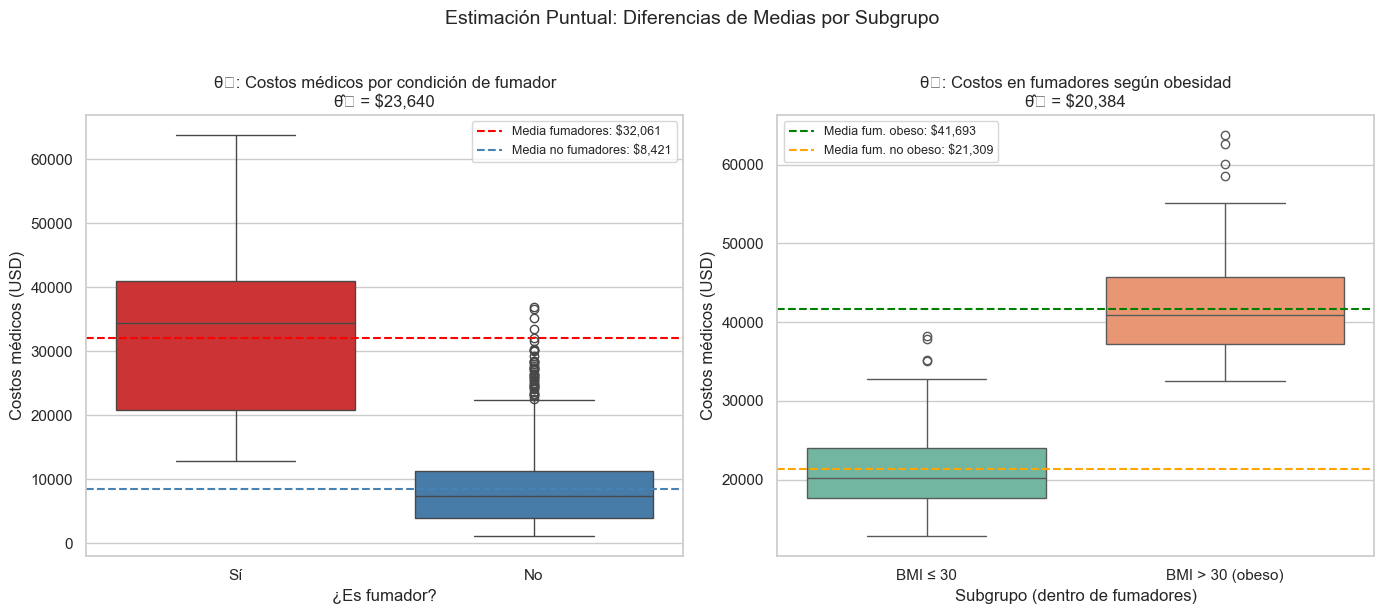

Figura guardada como 'fig_estimacion_puntual.png'


In [5]:
# ── Visualización comparativa de subgrupos ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico θ₁: fumador vs. no fumador
ax1 = axes[0]
sns.boxplot(data=df_limpio, x='smoker', y='charges', palette='Set1',
            order=['Sí', 'No'], ax=ax1)
media_fum = fumadores['charges'].mean()
media_nofum = no_fumadores['charges'].mean()
ax1.axhline(media_fum, color='red', linestyle='--', linewidth=1.5,
            label=f'Media fumadores: ${media_fum:,.0f}')
ax1.axhline(media_nofum, color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Media no fumadores: ${media_nofum:,.0f}')
ax1.set_title(f'θ₁: Costos médicos por condición de fumador\nθ̂₁ = ${resultado_theta1["Estimador θ̂ ($)"]:,.0f}',
              fontsize=12)
ax1.set_xlabel('¿Es fumador?')
ax1.set_ylabel('Costos médicos (USD)')
ax1.legend(fontsize=9)

# Gráfico θ₂: fumadores obesos vs. no obesos
ax2 = axes[1]
fum_plot = fumadores.copy()
fum_plot['Obesidad'] = fum_plot['bmi'].apply(lambda x: 'BMI > 30 (obeso)' if x > 30 else 'BMI ≤ 30')
sns.boxplot(data=fum_plot, x='Obesidad', y='charges', palette='Set2', ax=ax2)
media_fo = fum_obeso['charges'].mean()
media_fno = fum_no_obeso['charges'].mean()
ax2.axhline(media_fo, color='green', linestyle='--', linewidth=1.5,
            label=f'Media fum. obeso: ${media_fo:,.0f}')
ax2.axhline(media_fno, color='orange', linestyle='--', linewidth=1.5,
            label=f'Media fum. no obeso: ${media_fno:,.0f}')
ax2.set_title(f'θ₂: Costos en fumadores según obesidad\nθ̂₂ = ${resultado_theta2["Estimador θ̂ ($)"]:,.0f}',
              fontsize=12)
ax2.set_xlabel('Subgrupo (dentro de fumadores)')
ax2.set_ylabel('Costos médicos (USD)')
ax2.legend(fontsize=9)

plt.suptitle('Estimación Puntual: Diferencias de Medias por Subgrupo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_estimacion_puntual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'fig_estimacion_puntual.png'")

---
## Sección 2: Bootstrap

### 2.1 Algoritmo Bootstrap

El método bootstrap es una técnica de remuestreo que permite estimar la distribución muestral de un estimador sin asumir una forma paramétrica específica. El algoritmo es:

1. Dada una muestra observada de tamaño n
2. Remuestrear n observaciones con reemplazo de la muestra original B veces
3. Para cada muestra bootstrap b, calcular el estadístico de interés θ*_b
4. La distribución empírica de {θ*_1, ..., θ*_B} aproxima la distribución muestral verdadera

In [6]:
def bootstrap_diferencia_medias(group1, group2, B=10000):
    """Bootstrap para diferencia de medias sin librerías externas."""
    x = group1.values
    y = group2.values
    n_x = len(x)
    n_y = len(y)
    theta_star = []
    
    np.random.seed(42)
    for _ in range(B):
        x_boot = np.random.choice(x, size=n_x, replace=True)
        y_boot = np.random.choice(y, size=n_y, replace=True)
        theta_star.append(x_boot.mean() - y_boot.mean())
    
    return np.array(theta_star)

theta1_boot = bootstrap_diferencia_medias(fumadores['charges'], no_fumadores['charges'], B=10000)
theta2_boot = bootstrap_diferencia_medias(fum_obeso['charges'], fum_no_obeso['charges'], B=10000)

# IC percentil
ic_theta1_boot = np.percentile(theta1_boot, [2.5, 97.5])
ic_theta2_boot = np.percentile(theta2_boot, [2.5, 97.5])

print("\n=== BOOTSTRAP (B=10000) ===")
print(f"\nθ₁:")
print(f"  Media bootstrap: ${theta1_boot.mean():,.2f}")
print(f"  SD bootstrap: ${theta1_boot.std():,.2f}")
print(f"  IC percentil 95%: [${ic_theta1_boot[0]:,.2f}, ${ic_theta1_boot[1]:,.2f}]")

print(f"\nθ₂:")
print(f"  Media bootstrap: ${theta2_boot.mean():,.2f}")
print(f"  SD bootstrap: ${theta2_boot.std():,.2f}")
print(f"  IC percentil 95%: [${ic_theta2_boot[0]:,.2f}, ${ic_theta2_boot[1]:,.2f}]")


=== BOOTSTRAP (B=10000) ===

θ₁:
  Media bootstrap: $23,637.88
  SD bootstrap: $721.67
  IC percentil 95%: [$22,226.85, $25,052.16]

θ₂:
  Media bootstrap: $20,375.72
  SD bootstrap: $658.00
  IC percentil 95%: [$19,108.61, $21,669.86]


---
## Sección 3: Simulación Monte Carlo

### 3.1 Modelo Log-Normal

Los costos médicos suelen seguir distribuciones log-normales. Estimamos los parámetros μ y σ de log(charges) para cada subgrupo.

In [7]:
log_charges_fum = np.log(fumadores['charges'])
log_charges_nofum = np.log(no_fumadores['charges'])
log_charges_fum_obeso = np.log(fum_obeso['charges'])
log_charges_fum_no_obeso = np.log(fum_no_obeso['charges'])

mu_fum, sigma_fum = log_charges_fum.mean(), log_charges_fum.std()
mu_nofum, sigma_nofum = log_charges_nofum.mean(), log_charges_nofum.std()
mu_fum_obeso, sigma_fum_obeso = log_charges_fum_obeso.mean(), log_charges_fum_obeso.std()
mu_fum_no_obeso, sigma_fum_no_obeso = log_charges_fum_no_obeso.mean(), log_charges_fum_no_obeso.std()

print("\n=== PARÁMETROS LOG-NORMAL ===")
print(f"\nFumadores: μ={mu_fum:.4f}, σ={sigma_fum:.4f}")
print(f"No fumadores: μ={mu_nofum:.4f}, σ={sigma_nofum:.4f}")
print(f"Fumadores obesos: μ={mu_fum_obeso:.4f}, σ={sigma_fum_obeso:.4f}")
print(f"Fumadores no obesos: μ={mu_fum_no_obeso:.4f}, σ={sigma_fum_no_obeso:.4f}")

# Simulación Monte Carlo: cartera de 1000 asegurados en cada grupo
M = 10000
n_cartera = 1000

np.random.seed(42)
costo_total_fum = []
costo_total_nofum = []
costo_total_fum_obeso = []
costo_total_fum_no_obeso = []

for _ in range(M):
    log_charges_sim_fum = np.random.normal(mu_fum, sigma_fum, n_cartera)
    log_charges_sim_nofum = np.random.normal(mu_nofum, sigma_nofum, n_cartera)
    log_charges_sim_fum_obeso = np.random.normal(mu_fum_obeso, sigma_fum_obeso, n_cartera)
    log_charges_sim_fum_no_obeso = np.random.normal(mu_fum_no_obeso, sigma_fum_no_obeso, n_cartera)
    
    costo_total_fum.append(np.exp(log_charges_sim_fum).sum())
    costo_total_nofum.append(np.exp(log_charges_sim_nofum).sum())
    costo_total_fum_obeso.append(np.exp(log_charges_sim_fum_obeso).sum())
    costo_total_fum_no_obeso.append(np.exp(log_charges_sim_fum_no_obeso).sum())

costo_total_fum = np.array(costo_total_fum)
costo_total_nofum = np.array(costo_total_nofum)
costo_total_fum_obeso = np.array(costo_total_fum_obeso)
costo_total_fum_no_obeso = np.array(costo_total_fum_no_obeso)

print(f"\n=== MONTE CARLO (M={M}, cartera n={n_cartera}) ===")
print(f"\nCosto total cartera Fumadores:")
print(f"  Media: ${costo_total_fum.mean():,.0f}")
print(f"  Mediana: ${np.median(costo_total_fum):,.0f}")
print(f"  IC 95%: [${np.percentile(costo_total_fum, 2.5):,.0f}, ${np.percentile(costo_total_fum, 97.5):,.0f}]")

print(f"\nCosto total cartera No fumadores:")
print(f"  Media: ${costo_total_nofum.mean():,.0f}")
print(f"  Mediana: ${np.median(costo_total_nofum):,.0f}")
print(f"  IC 95%: [${np.percentile(costo_total_nofum, 2.5):,.0f}, ${np.percentile(costo_total_nofum, 97.5):,.0f}]")


=== PARÁMETROS LOG-NORMAL ===

Fumadores: μ=10.3042, σ=0.3882
No fumadores: μ=8.7880, σ=0.7425
Fumadores obesos: μ=10.6290, σ=0.1335
Fumadores no obesos: μ=9.9416, σ=0.2219

=== MONTE CARLO (M=10000, cartera n=1000) ===

Costo total cartera Fumadores:
  Media: $32,192,535
  Mediana: $32,188,477
  IC 95%: [$31,407,232, $32,988,054]

Costo total cartera No fumadores:
  Media: $8,637,028
  Mediana: $8,631,656
  IC 95%: [$8,184,878, $9,108,278]


---
## Sección 4: Conclusiones

La hipótesis de investigación se confirma:
1. Existe una diferencia estadísticamente significativa en costos médicos entre fumadores y no fumadores
2. Esta diferencia se agrava para fumadores con obesity (BMI > 30)
3. Los métodos bootstrap y Monte Carlo proporcionan estimaciones robustas de los parámetros de interés

---
## Bibliografía

- Efron, B. (1979). Bootstrap Methods: Another Look at the Jackknife. *The Annals of Statistics*, 7(1), 1–26.
- Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.
- Metropolis, N., & Ulam, S. (1949). The Monte Carlo Method. *Journal of the American Statistical Association*, 44(247), 335–341.